# Statistics from Monte Carlo simulations

In [1]:
import itertools
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = [12, 12]

import agents
import events
import timeseries_tools
from mc_statistics import *

In [2]:
simulation_end_time = 120

# chi chi
df1 = 1
df2 = 4

def service_time(customer):
    return np.random.chisquare(df2)

def interarr_time():
    return np.random.chisquare(df1)

amount_cashiers = 5

simulation_size = 300

In [3]:
# generate simulation seeds
np.random.seed(17)
seeds = np.random.randint(1e10, size=simulation_size)
start_time = time.time()

# run Monte Carlo simulation
simulation_results = list(map(lambda seed: simulate(seed, simulation_end_time, service_time, interarr_time, amount_cashiers), seeds))

print(f"simulation run took {(time.time()-start_time):.2f} seconds")

simulation run took 0.26 seconds


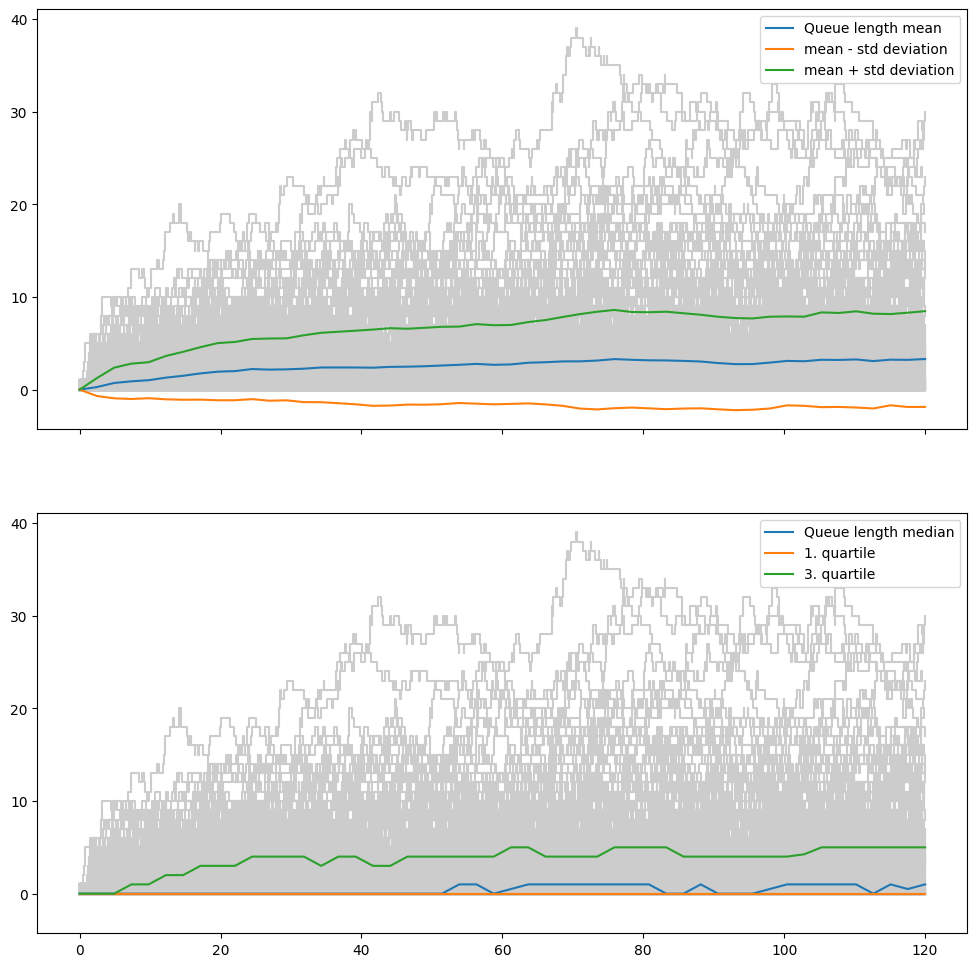

In [4]:
# plot queue length
queue_length_data = [result[0] for result in simulation_results]
plot_queue_length_statistics(queue_length_data, simulation_end_time)


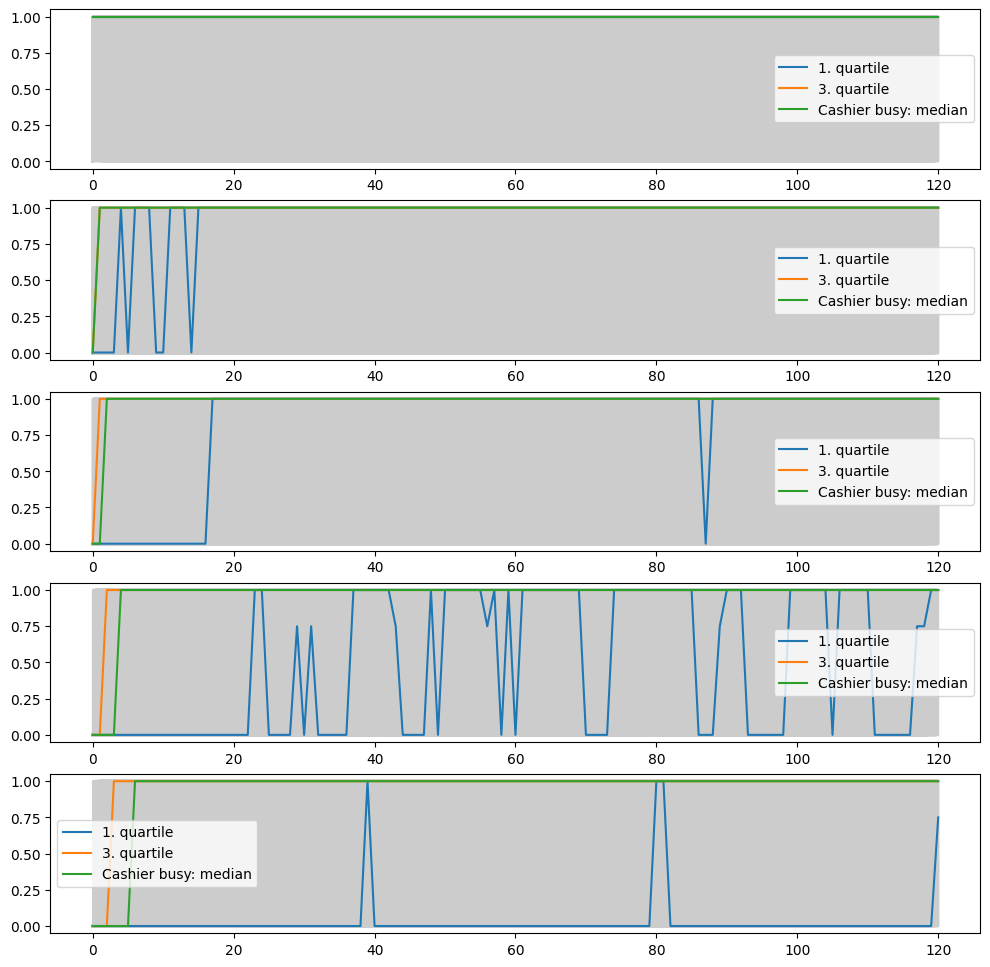

In [5]:
# plot how busy the cashiers are
cashiers_busy_data = [result[1] for result in simulation_results]
plot_cashiers_busy(cashiers_busy_data, simulation_end_time)


In [6]:
# print mean and sd of customer waiting time
customer_waiting_times = list(itertools.chain.from_iterable([result[2] for result in simulation_results]))
print("Customer waiting time:")
print(f"\tmean: {np.mean(customer_waiting_times)}")
print(f"\tstandard deviation: {np.std(customer_waiting_times, ddof=1)}")
print(f"\t1. quartile: {np.quantile(customer_waiting_times, q=0.25)}")
print(f"\tmedian: {np.median(customer_waiting_times)}")
print(f"\t3. quartile: {np.quantile(customer_waiting_times, q=0.75)}")
print()

# cashier throughput
cashier_throughput = np.array([result[3] for result in simulation_results]).T
print("Cashier throughput:")
print(f"\tmean: {np.mean(cashier_throughput, axis=1)}")
print(f"\tstandard deviation: {np.std(cashier_throughput, axis=1, ddof=1)}")
print(f"\t1. quartile: {np.quantile(cashier_throughput, axis=1, q=0.25)}")
print(f"\tmedian: {np.median(cashier_throughput, axis=1)}")
print(f"\t3. quartile: {np.quantile(cashier_throughput, axis=1, q=0.75)}")
print()

Customer waiting time:
	mean: 2.407377467759639
	standard deviation: 3.595355599098622
	1. quartile: 0.0
	median: 0.8463560398388523
	3. quartile: 3.6263084033396282

Cashier throughput:
	mean: [0.21266667 0.20161111 0.19202778 0.18241667 0.16797222]
	standard deviation: [0.02831054 0.02964858 0.03253088 0.0360558  0.03902625]
	1. quartile: [0.19166667 0.18333333 0.175      0.15833333 0.14166667]
	median: [0.20833333 0.2        0.19166667 0.18333333 0.16666667]
	3. quartile: [0.23333333 0.21666667 0.20833333 0.20833333 0.19166667]

